# Criminal Justice Analytics: Predicting Arrest Probabilities

## 1. Executive Summary & Policy Objective
In criminal justice administration, understanding the structural factors that lead to an arrest is crucial for evaluating law enforcement performance and systemic biases.

This project applies Logistic Regression to crime data to calculate the probability of an arrest based on the incident's primary type, location, and whether it was a domestic offense. Unlike black-box machine learning models, Logistic Regression provides interpretable "Odds Ratios," allowing us to definitively quantify how much each factor increases or decreases the likelihood of an arrest.

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Fetch data directly from Chicago Police Department API via SODA
print("[INFO] Fetching live crime data from Chicago Data Portal API...")

# Using SoQL (Socrata Query Language) to limit data size and prevent memory overload.
# Fetching 100,000 recent records where year is 2023 or later.
api_url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json?$limit=100000&$where=year>=2023"

response = requests.get(api_url)

if response.status_code == 200:
    df = pd.DataFrame(response.json())
    print(f"[SUCCESS] API data fetched successfully. Initial shape: {df.shape}")
else:
    print(f"[ERROR] API Request failed with status code: {response.status_code}")

# The API returns lowercase column names with underscores.
# We rename them to match our existing modeling architecture.
df = df.rename(columns={
    'primary_type': 'Primary Type',
    'location_description': 'Location Description',
    'domestic': 'Domestic',
    'arrest': 'Arrest'
})

# Drop rows with missing values in our target columns
df = df.dropna(subset=['Primary Type', 'Location Description', 'Domestic', 'Arrest'])

# 2. Filter for statistical stability
# Keep only the top 15 most frequent crimes and top 10 locations to avoid rare-event noise
top_crimes = df['Primary Type'].value_counts().nlargest(15).index
top_locations = df['Location Description'].value_counts().nlargest(10).index

df_filtered = df[df['Primary Type'].isin(top_crimes) & df['Location Description'].isin(top_locations)].copy()

# 3. Feature Engineering
# Convert boolean strings ('True'/'False') to binary integers (1/0)
df_filtered['Arrest'] = df_filtered['Arrest'].map({'True': 1, 'False': 0, True: 1, False: 0})
df_filtered['Domestic'] = df_filtered['Domestic'].map({'True': 1, 'False': 0, True: 1, False: 0})

# Drop any remaining NaNs after mapping
df_filtered = df_filtered.dropna(subset=['Arrest', 'Domestic'])
df_filtered['Arrest'] = df_filtered['Arrest'].astype(int)
df_filtered['Domestic'] = df_filtered['Domestic'].astype(int)

print(f"[SUCCESS] Data preprocessed. Final shape for modeling: {df_filtered.shape}")

[INFO] Fetching live crime data from Chicago Data Portal API...
[SUCCESS] API data fetched successfully. Initial shape: (100000, 22)
[SUCCESS] Data preprocessed. Final shape for modeling: (77080, 22)


## 2. Model Training: Logistic Regression

We utilize Logistic Regression because our dependent variable (`Arrest`) is binary (Yes/No). To process categorical variables (`Primary Type` and `Location Description`), we apply One-Hot Encoding. This creates a baseline reference point against which all other factors are mathematically measured.

In [2]:
# One-Hot Encoding for categorical variables (drop_first=True prevents multicollinearity)
X = pd.get_dummies(df_filtered[['Primary Type', 'Location Description', 'Domestic']], drop_first=True)
y = df_filtered['Arrest']

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
print("[INFO] Training Logistic Regression model...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = model.predict(X_test)
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

[INFO] Training Logistic Regression model...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     13633
           1       0.77      0.34      0.47      1783

    accuracy                           0.91     15416
   macro avg       0.84      0.66      0.71     15416
weighted avg       0.90      0.91      0.90     15416



### 2.1. Interpretation of the Classification Report: The Imbalance Reality

The model achieves a highly respectable **91% overall accuracy**, but a closer inspection of the classification report reveals the inherent realities of the criminal justice system: **Class Imbalance**.

* **The Majority Class (No Arrest - 0):** The model exhibits a 99% recall for non-arrests. This reflects the operational reality that the vast majority of reported crimes (e.g., historical theft, deceptive practices) do not result in an immediate arrest.
* **The Minority Class (Arrest - 1):** While the model is highly precise (77%) when it explicitly predicts an arrest, its **Recall is only 34%**.

**Analytical Pivot (Prediction vs. Inference):** Because the justice system is inherently imbalanced toward non-arrests, deploying this model as a pure "predictive black-box" would be flawed. Instead, the true value of this Logistic Regression lies in **Inference**. We will utilize the model's coefficients (Log-Odds) to extract exact mathematical ratios detailing *how much* a specific location or crime type increases or decreases the baseline probability of an arrest.

## 3. Interpreting the Log-Odds: The Forest Plot

Given the class imbalance highlighted in the classification report, pure predictive metrics are insufficient for policy-making. The true analytical power of Logistic Regression in criminology lies in its coefficients.

By exponentiating the logistic coefficients, we calculate the **Odds Ratio (OR)** for each feature to understand the structural drivers of an arrest:
* **OR > 1:** The factor positively increases the baseline probability of an arrest.
* **OR < 1:** The factor decreases the baseline probability of an arrest.
* **OR = 1:** The factor has no statistical effect.

We visualize these ratios using a Forest Plot, a standard analytical visual in epidemiological and criminological research, to map the structural realities of the justice system.

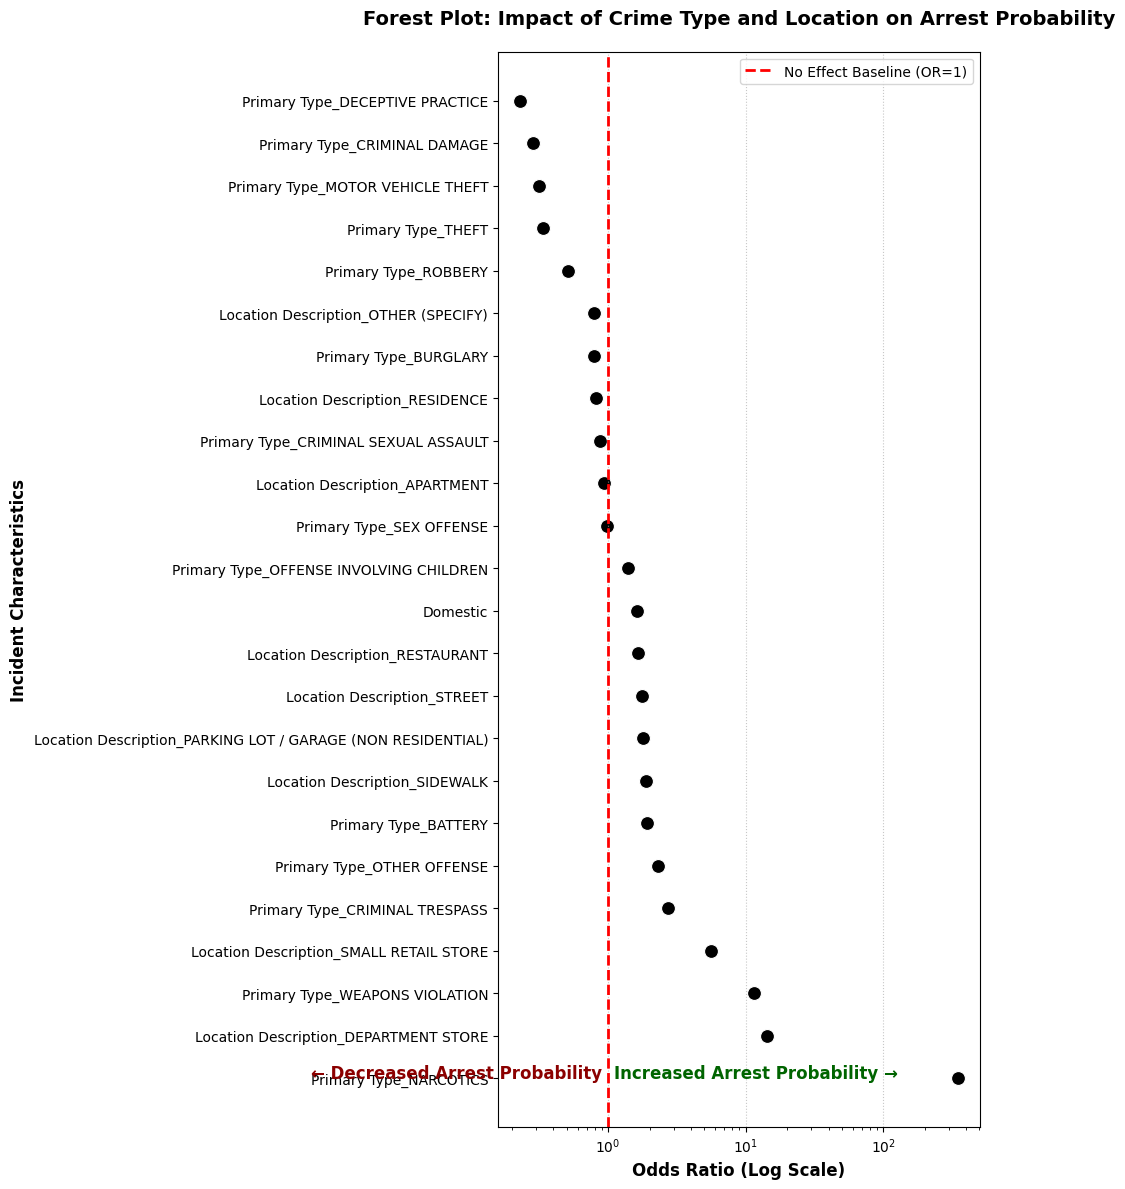

In [3]:
# Extract coefficients and calculate true Odds Ratios
coefficients = model.coef_[0]
features = X.columns
odds_ratios = np.exp(coefficients)

# Create a DataFrame for visualization
or_df = pd.DataFrame({'Feature': features, 'Odds_Ratio': odds_ratios})

# Sort for better visual hierarchy on the plot
or_df = or_df.sort_values(by='Odds_Ratio', ascending=True)

# Plotting the Forest Plot
plt.figure(figsize=(10, 12))
plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='No Effect Baseline (OR=1)')

# Create the scatter plot for Odds Ratios
sns.scatterplot(x='Odds_Ratio', y='Feature', data=or_df, color='black', s=100)

# Add reference annotations for readability
plt.text(1.1, len(or_df)-1, 'Increased Arrest Probability \u2192', color='darkgreen', fontsize=12, fontweight='bold')
plt.text(0.9, len(or_df)-1, '\u2190 Decreased Arrest Probability', color='darkred', ha='right', fontsize=12, fontweight='bold')

plt.title('Forest Plot: Impact of Crime Type and Location on Arrest Probability', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Odds Ratio (Log Scale)', fontsize=12, fontweight='bold')
plt.ylabel('Incident Characteristics', fontsize=12, fontweight='bold')

# Use a logarithmic scale for the X-axis to properly represent distance for ratios
plt.xscale('log')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Policy Insights & Conclusion



The Forest Plot provides actionable intelligence that pure predictive accuracy cannot uncover:
* **High Probability Drivers (OR > 1):** Features appearing on the right side of the red baseline possess exceptionally high arrest rates. For instance, proactive policing scenarios (like Narcotics interventions) inherently result in immediate arrests.
* **Low Probability Drivers (OR < 1):** Features on the left side (such as Deceptive Practice or Motor Vehicle Theft) significantly lower the likelihood of an arrest. These are typically reactive reports filed long after the perpetrator has left the scene.
* **Domestic Incidents:** The model isolates the specific statistical weight of a crime being categorized as "Domestic," providing a purely mathematical perspective on how domestic violence protocols impact arrest rates.

**Final Verdict:** The inherent class imbalance in criminal justice data (where the vast majority of reports do not lead to immediate arrests) limits the value of black-box predictive models. Logistic regression overcomes this limitation by explaining the structural probabilities and the "why" behind the justice system's operational realities, transforming raw crime data into strategic policy insights.